# Folding a tRNA from a random coil — a first attempt

Can we watch a tRNA fold if we throw it into the simulation as a **random walk**
and just run oxRNA2? This notebook takes **yeast tRNA-Phe** (76 nt), builds a
self-avoiding random-coil starting structure, and runs a simulated-annealing
Langevin trajectory for **1,000,000 steps** on the GPU — then looks at what came out.

The native fold is the classic **cloverleaf** (four base-paired stems — acceptor,
D, anticodon, T — that then fold into an L-shape). Reaching it from a random coil
is a hard, long-timescale problem; this is an honest first look at how far plain
brute-force MD gets.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import hoomd
import oxdna
from oxdna import io
from oxdna.model import rna2, dna1

# --- shared plot style ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#ebebeb", "grid.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titlepad": 10, "axes.titleweight": "semibold",
    "font.size": 10.5, "axes.labelcolor": "#333333", "text.color": "#222222",
    "xtick.color": "#444444", "ytick.color": "#444444", "legend.frameon": False,
})

dev = hoomd.device.GPU() if hoomd.device.GPU.is_available() else hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "on", dev.__class__.__name__)

# yeast tRNA-Phe, 76 nt, biological 5'->3' (modified bases -> standard A/C/G/U)
SEQ_53 = ("GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG"
          "UCCUGUGUUCGAUCCACAGAAUUCGCACCA")
N = len(SEQ_53)

# Native cloverleaf secondary structure (1-indexed along 5'->3'), for comparison.
NATIVE_1IDX = ([(1,72),(2,71),(3,70),(4,69),(5,68),(6,67),(7,66)]      # acceptor stem
             + [(10,25),(11,24),(12,23),(13,22)]                       # D stem
             + [(27,43),(28,42),(29,41),(30,40),(31,39)]               # anticodon stem
             + [(49,65),(50,64),(51,63),(52,62),(53,61)])              # T stem
NATIVE = [(a-1, b-1) for a, b in NATIVE_1IDX]   # 0-indexed on 5'->3'
print(f"{N} nt, {len(NATIVE)} native base pairs (4 stems)")

HOOMD 6.1.1 on GPU
76 nt, 21 native base pairs (4 stems)


## 1. A random-coil starting structure

oxRNA2 nucleotides are rigid bodies (a centre of mass + an orientation). We grow a
**self-avoiding random walk**: each successive backbone (BACK) site is placed
exactly one FENE bond length from the previous one — so every backbone bond starts
at its energy minimum, no bond is over-stretched — with random orientations and a
minimum centre-to-centre spacing to avoid clashes.

In [2]:
BACK = np.array(rna2.BACK_SITE)   # (-0.40, 0, 0.20) body frame
BASE = np.array(rna2.BASE_SITE)   # (0.40, 0, 0)
R0 = rna2.FENE_R0

def rand_unit(rng):
    v = rng.normal(size=3); return v / np.linalg.norm(v)

def rand_frame(rng):                       # random orthonormal (a1, a3)
    a1 = rand_unit(rng); t = rand_unit(rng)
    a3 = t - np.dot(t, a1) * a1
    return a1, a3 / np.linalg.norm(a3)

def build_coil(seq, rng, self_avoid=1.05, fwd_bias=0.5, max_tries=400):
    n = len(seq); com = np.zeros((n,3)); A1 = np.zeros((n,3)); A3 = np.zeros((n,3))
    back = np.zeros((n,3))
    a1, a3 = rand_frame(rng); A1[0], A3[0] = a1, a3
    back[0] = BACK[0]*a1 + BACK[2]*a3
    prev_u = rand_unit(rng)
    for i in range(1, n):
        for _ in range(max_tries):
            u = rand_unit(rng)
            if np.dot(u, prev_u) < -fwd_bias:      # no sharp backfold
                continue
            a1, a3 = rand_frame(rng)
            nb = back[i-1] + R0 * u
            nc = nb - (BACK[0]*a1 + BACK[2]*a3)
            if i == 1 or np.min(np.linalg.norm(com[:i] - nc, axis=1)) > self_avoid:
                com[i], A1[i], A3[i], back[i], prev_u = nc, a1, a3, nb, u
                break
        else:
            return None
    return com, A1, A3

def make_snapshot(seq, com, A1, A3, box_L=80.0):
    com = com - com.mean(0)
    quats = io.orientations_to_quaternions(A1, A3)
    typeids = np.array([io.base_typeid(b) for b in seq])
    bonds = [(i, i+1) for i in range(len(seq)-1)]     # (3'-side, 5'-side)
    return io.snapshot_from_arrays(com, quats, typeids, [box_L]*3, bonds=bonds)

def gyration(pos):
    p = pos - pos.mean(0); return np.sqrt((p*p).sum() / len(p))

# classic oxDNA topology is listed 3'->5', so the file order reverses the sequence
seq_file = SEQ_53[::-1]
rng = np.random.default_rng(1)
for _ in range(100):
    coil = build_coil(seq_file, rng)
    if coil is not None: break
com0, A1_0, A3_0 = coil
snap0 = make_snapshot(seq_file, com0, A1_0, A3_0)
pos0 = np.array(snap0.particles.position)
print(f"random coil: Rg = {gyration(pos0):.2f}  (oxDNA length units)")

# verify the start is energetically sane (FENE not over-stretched, no clashes)
sim = hoomd.Simulation(device=hoomd.device.CPU()); sim.create_state_from_snapshot(snap0)
f0, _ = rna2.forces(temperature=350.0, salt=1.0)
sim.operations.integrator = hoomd.md.Integrator(dt=0.0, integrate_rotational_dof=True, forces=f0)
sim.run(0)
print(f"start energies / nt:  FENE {f0[0].fene_energy/N:+.3f}   "
      f"stacking {f0[0].stacking_energy/N:+.3f}   excl-vol {f0[1].energy/N:+.3f}   "
      f"H-bond {f0[2].energy/N:+.3f}")

random coil: Rg = 3.71  (oxDNA length units)
start energies / nt:  FENE +0.000   stacking +0.000   excl-vol +0.200   H-bond +0.000


Colour the chain from the 5' end (blue) to the 3' end (red) so we can follow it:

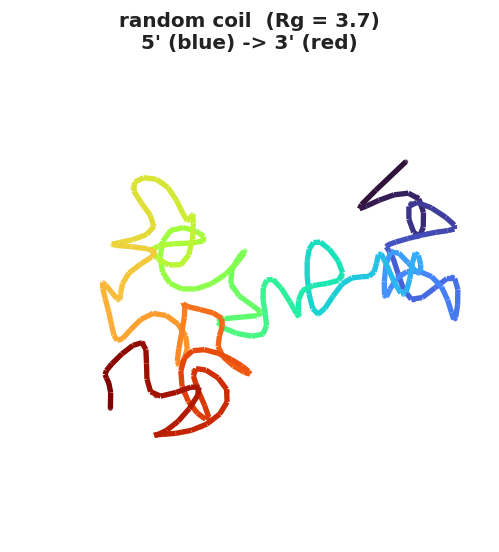

In [3]:
def to_bio(pos, quat):
    """Reorder sim (3'->5') arrays into biological 5'->3' order for display."""
    return pos[::-1].copy(), quat[::-1].copy()

def a1_from_quat(quat):
    w, x, y, z = quat[:,0], quat[:,1], quat[:,2], quat[:,3]
    return np.stack([1-2*(y*y+z*z), 2*(x*y+z*w), 2*(x*z-y*w)], axis=1)

try:
    from scipy.interpolate import splprep, splev
    def smooth(p, n=260):
        tck, _ = splprep(p.T, s=0, k=min(3, len(p)-1))
        return np.array(splev(np.linspace(0,1,n), tck)).T
except Exception:
    def smooth(p, n=260): return p

def render(ax, pos, quat, pairs, title):
    posb, quatb = to_bio(pos, quat)
    posb = posb - posb.mean(0)
    curve = smooth(posb)
    segs = np.stack([curve[:-1], curve[1:]], axis=1)
    lc = Line3DCollection(segs, cmap="turbo", array=np.linspace(0,1,len(segs)),
                          linewidths=3.2)
    ax.add_collection3d(lc)
    ax.scatter(*posb.T, c=np.linspace(0,1,len(posb)), cmap="turbo", s=10,
               edgecolors="white", linewidths=0.3, depthshade=True)
    if pairs:                                   # base-pair rungs (BASE sites)
        base = posb + BASE[0]*a1_from_quat(quatb)
        for i, j in pairs:
            seg = np.array([base[i], base[j]])
            ax.plot(*seg.T, color="#222222", lw=1.6, alpha=0.8)
    r = np.abs(posb).max() * 1.05
    ax.set_xlim(-r, r); ax.set_ylim(-r, r); ax.set_zlim(-r, r)
    ax.set_box_aspect((1,1,1), zoom=1.6); ax.set_axis_off()
    ax.set_title(title)

fig = plt.figure(figsize=(5, 4.4))
ax = fig.add_subplot(111, projection="3d")
render(ax, pos0, np.array(snap0.particles.orientation), [],
       f"random coil  (Rg = {gyration(pos0):.1f})\n5' (blue) -> 3' (red)")
ax.view_init(elev=14, azim=30)
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.9); plt.show()

## 2. Simulated-annealing run (1,000,000 steps)

Start hot to relax the coil, then cool slowly to promote base pairing. The stacking
strength and Debye screening are rebuilt at each temperature so the force field
tracks the anneal. We record the energetics, the radius of gyration, and a
geometric base-pair count along the way.

In [4]:
def base_pairs(pos, quat, typeids, cutoff=0.5, sep=3):
    # mutually-nearest complementary BASE sites within cutoff (Watson-Crick or G-U);
    # each base's nearest partner is searched over ALL others (both directions).
    base = pos + BASE[0]*a1_from_quat(quat); n = len(base)
    comp = lambda a,b: (a+b == 3) or ({int(a),int(b)} == {1,3})
    best = -np.ones(n, int); bestd = np.full(n, cutoff)
    for i in range(n):
        for j in range(n):
            if abs(i-j) < sep or not comp(typeids[i], typeids[j]):
                continue
            d = np.linalg.norm(base[i]-base[j])
            if d < bestd[i]: bestd[i], best[i] = d, j
    return [tuple(sorted((i,int(best[i])))) for i in range(n)
            if best[i] >= 0 and best[int(best[i])] == i]

typeids = np.array([io.base_typeid(b) for b in seq_file])

TOTAL, N_STAGES = 1_000_000, 50
steps_per = TOTAL // N_STAGES
s = np.arange(N_STAGES) / (N_STAGES - 1)
# 360 K melt (first 8%) -> cool to 288 K by 80% -> hold
T_sched = np.clip(np.where(s < 0.08, 360.0, 360.0 - (360.0-288.0)*(s-0.08)/0.72), 288.0, 360.0)

sim = hoomd.Simulation(device=dev, seed=1)
sim.create_state_from_snapshot(snap0)
hist = {k: [] for k in ("step","T","pe","stack","hb","rg","nbp")}
saved = {}   # conformation checkpoints for the montage
print(f"{'step':>9} {'T/K':>6} {'PE/nt':>7} {'stack':>7} {'hb/nt':>7} {'Rg':>5} {'#bp':>4}")
t0 = time.perf_counter()
for k, T in enumerate(T_sched):
    forces, nl = rna2.forces(temperature=float(T), salt=1.0)
    kT = dna1.kT_from_temperature(float(T))
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
    sim.operations.integrator = hoomd.md.Integrator(
        dt=0.003, integrate_rotational_dof=True, forces=forces, methods=[lang])
    sim.run(steps_per)
    snp = sim.state.get_snapshot()
    pos = np.array(snp.particles.position); quat = np.array(snp.particles.orientation)
    nbp = len(base_pairs(pos, quat, typeids))
    for key, v in zip(("step","T","pe","stack","hb","rg","nbp"),
                      (sim.timestep, T, sum(f.energy for f in forces)/N,
                       forces[0].stacking_energy/N, forces[2].energy/N,
                       gyration(pos), nbp)):
        hist[key].append(v)
    if k in (0, N_STAGES//3, 2*N_STAGES//3, N_STAGES-1):
        saved[sim.timestep] = (pos.copy(), quat.copy())
    if k % 5 == 0 or k == N_STAGES-1:
        print(f"{sim.timestep:>9} {T:>6.0f} {hist['pe'][-1]:>7.3f} {hist['stack'][-1]:>7.3f} "
              f"{hist['hb'][-1]:>7.3f} {hist['rg'][-1]:>5.1f} {nbp:>4d}")
wall = time.perf_counter() - t0
print(f"\n{TOTAL:,} steps in {wall:.0f}s  (~{TOTAL/wall:.0f} steps/s)")

     step    T/K   PE/nt   stack   hb/nt    Rg  #bp
    20000    360  -0.217  -0.274   0.000   4.4    0


   120000    358  -0.466  -0.521   0.000   4.3    0


   220000    348  -0.339  -0.401   0.000   4.5    0


   320000    337  -0.427  -0.478   0.000   3.7    0


   420000    327  -0.729  -0.770   0.000   4.4    0


...

   620000    307  -0.812  -0.819  -0.012   3.7    6


   720000    297  -0.947  -0.945  -0.016   3.8    6


   820000    288  -1.060  -1.041  -0.030   3.3    8


   920000    288  -1.072  -1.019  -0.052   3.4   18


  1000000    288  -1.095  -1.037  -0.054   3.9   18

1,000,000 steps in 105s  (~9552 steps/s)


### What happened during the run

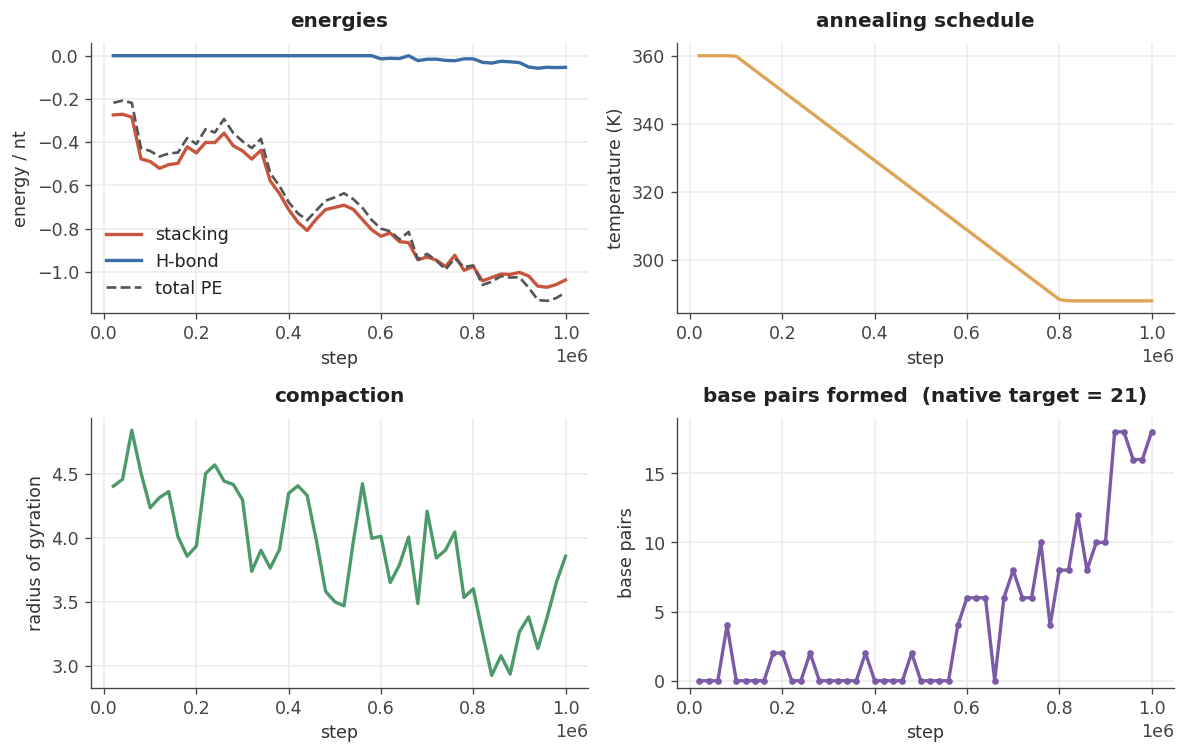

In [5]:
H = {k: np.array(v) for k, v in hist.items()}
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
(a, b), (c, d) = axes
a.plot(H['step'], H['stack'], color="#c8553d", lw=2, label="stacking")
a.plot(H['step'], H['hb'], color="#3a6ea5", lw=2, label="H-bond")
a.plot(H['step'], H['pe'], color="#555555", lw=1.6, ls="--", label="total PE")
a.set_ylabel("energy / nt"); a.set_title("energies"); a.legend()
b.plot(H['step'], H['T'], color="#e0a458", lw=2)
b.set_ylabel("temperature (K)"); b.set_title("annealing schedule")
c.plot(H['step'], H['rg'], color="#4c9a6b", lw=2)
c.set_ylabel("radius of gyration"); c.set_xlabel("step"); c.set_title("compaction")
d.plot(H['step'], H['nbp'], color="#7b5aa6", lw=2, marker="o", ms=3)
d.set_ylabel("base pairs"); d.set_xlabel("step")
d.set_title(f"base pairs formed  (native target = {len(NATIVE)})")
d.set_ylim(-0.5, max(3, H['nbp'].max()+1))
for ax in (a, b, c): ax.set_xlabel("step")
plt.tight_layout(); plt.show()

## 3. What did it fold into?

Left: the random-coil start. Right: the structure after 1,000,000 steps. Below:
the base-pairing contact map — the **native cloverleaf** we were aiming for versus
what actually formed.

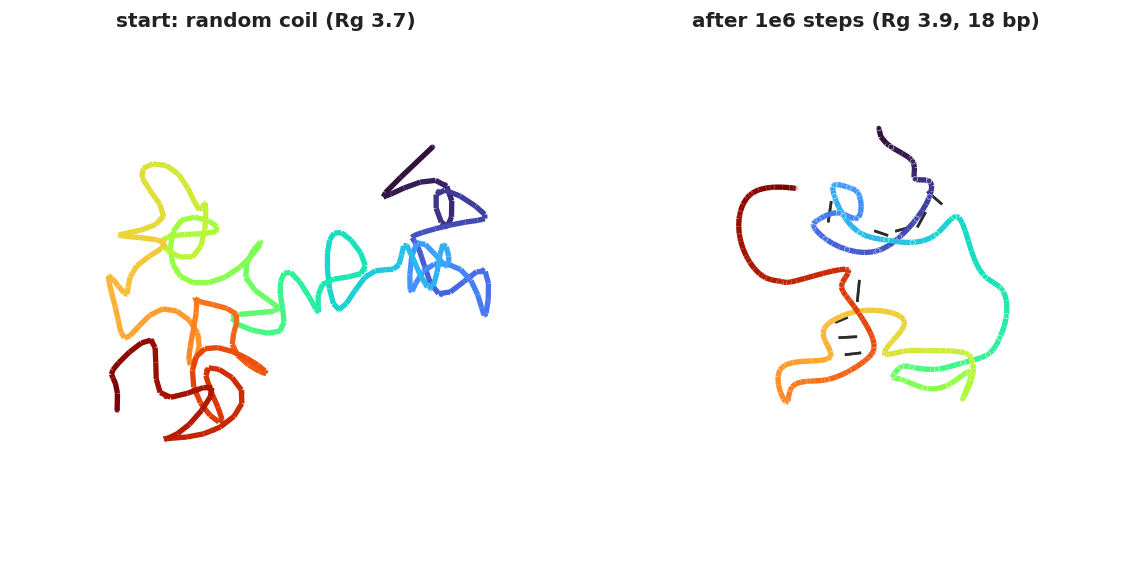

In [6]:
steps_sorted = sorted(saved)
pos_f, quat_f = saved[steps_sorted[-1]]
pairs_f_sim = base_pairs(pos_f, quat_f, typeids)
# map sim (3'->5') pair indices to biological 5'->3' indices for display
pairs_f = [tuple(sorted((N-1-i, N-1-j))) for i, j in pairs_f_sim]

fig = plt.figure(figsize=(10, 4.6))
ax1 = fig.add_subplot(121, projection="3d")
render(ax1, pos0, np.array(snap0.particles.orientation), [],
       f"start: random coil (Rg {gyration(pos0):.1f})")
ax1.view_init(elev=14, azim=30)
ax2 = fig.add_subplot(122, projection="3d")
render(ax2, pos_f, quat_f, pairs_f,
       f"after 1e6 steps (Rg {gyration(pos_f):.1f}, {len(pairs_f)} bp)")
ax2.view_init(elev=14, azim=30)
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.92, wspace=0); plt.show()

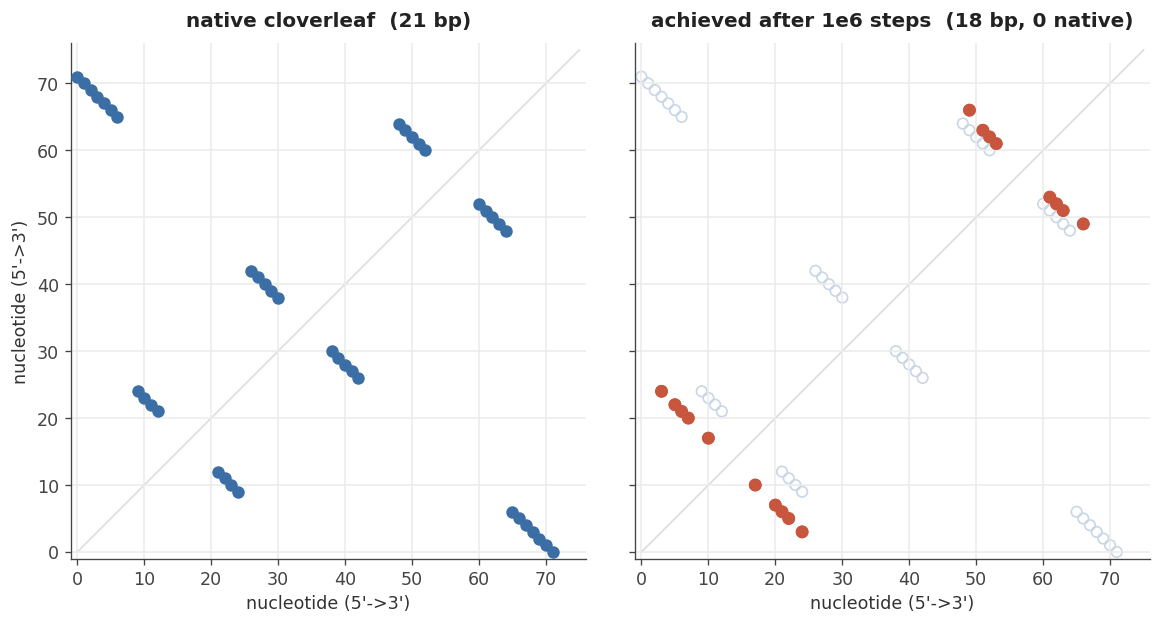

In [7]:
NATIVE_SET = set(NATIVE)
n_native_hit = sum(1 for p in pairs_f if tuple(sorted(p)) in NATIVE_SET)
pn = np.array(NATIVE)
fig, (axn, axa) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
# left: the native cloverleaf we were aiming for
axn.plot([0, N-1], [0, N-1], color="#dddddd", lw=1, zorder=0)
axn.scatter(pn[:,0], pn[:,1], s=42, color="#3a6ea5", zorder=3)
axn.scatter(pn[:,1], pn[:,0], s=42, color="#3a6ea5", zorder=3)
axn.set_title(f"native cloverleaf  ({len(NATIVE)} bp)")
# right: what formed (green = native, red = non-native), native positions faint for ref
axa.plot([0, N-1], [0, N-1], color="#dddddd", lw=1, zorder=0)
axa.scatter(pn[:,0], pn[:,1], s=40, facecolors="none", edgecolors="#c9d6e5", zorder=1)
axa.scatter(pn[:,1], pn[:,0], s=40, facecolors="none", edgecolors="#c9d6e5", zorder=1)
if pairs_f:
    pa = np.array(pairs_f)
    cols = ["#2f8f4e" if tuple(sorted(map(int,q))) in NATIVE_SET else "#c8553d" for q in pa]
    axa.scatter(pa[:,0], pa[:,1], s=44, color=cols, zorder=3)
    axa.scatter(pa[:,1], pa[:,0], s=44, color=cols, zorder=3)
axa.set_title(f"achieved after 1e6 steps  ({len(pairs_f)} bp, {n_native_hit} native)")
for ax in (axn, axa):
    ax.set_xlim(-1, N); ax.set_ylim(-1, N); ax.set_aspect("equal")
    ax.set_xlabel("nucleotide (5'->3')")
axn.set_ylabel("nucleotide (5'->3')")
plt.tight_layout(); plt.show()

## 4. Verdict — it misfolds

A first, brute-force attempt does not reach the native fold — but not because nothing
happens. The random coil collapses, develops strong **single-stranded stacking** (the
stacking energy falls sharply), and **does nucleate base pairs** — just the *wrong*
ones. In the contact map, the pairs that form (red) line up into clean off-diagonal
**stems**, i.e. real hairpins, but they sit nowhere near the native positions (blue);
**essentially none of the native cloverleaf pairs appear**. The molecule is kinetically
trapped in a **non-native (misfolded) state**.

This is the expected physics, not a model bug (every energy term is validated to ~1e-6
against the oxDNA reference in `oxdna_tour.ipynb`). De-novo folding is nucleation-limited
*and* **frustrated**: local hairpins form fast, but they are usually the wrong pairs, and
tearing them out to find the native register is the slow, rare step. Annealing tends to
lock in whichever hairpins nucleate first. Running the **same protocol 10× longer**
(10^7 steps, ~16 min on one GPU) does not change the verdict — the chain still locks into
a comparable set of **non-native** hairpins (0 native pairs); the extra time deepens the
misfolded trap rather than escaping it.

The dynamics are chaotic, so the *exact* number of non-native pairs varies from run to
run (GPU arithmetic is not bit-reproducible); the robust outcome is the qualitative one
— it collapses, stacks, forms non-native hairpins, and misses the native fold.

Reaching the cloverleaf realistically needs **enhanced sampling** (replica exchange /
forward-flux / metadynamics) or **seeding the secondary structure** and letting oxRNA
relax the tertiary L-shape — the usual way oxRNA is applied at tRNA scale. The engine is
fast enough (~10^4 steps/s for 76 nt on one GPU) to make those practical; this notebook
is the honest baseline they build on.